## Read the data

In [1]:
from astropy.io import fits

# 1. Open the file 
file_path = 'NIRSpec_IFU/COS-87259_NOBG_prism-clear_s3d.fits'
hdul = fits.open(file_path)

# 2. View the overall structure of HDUs in this file
print("File Information:")
hdul.info()
print("-" * 40)

# 3. Access a specific Extension (e.g., 'SCI' for Science)
sci_header = hdul['SCI'].header
sci_data = hdul['SCI'].data

# 4. Read the first 10 lines of the Header to understand metadata
print("First 10 Header Keywords:")
print(list(sci_header.items())[:10])
print("-" * 40)

# 5. Check the shape of the Data array
# For 3D IFU Spectra, it's (Wavelength, Y_Pixels, X_Pixels)
print("Data Shape:", sci_data.shape)

# Close the file when done to save memory
hdul.close()

File Information:
Filename: NIRSpec_IFU/COS-87259_NOBG_prism-clear_s3d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     369   ()      
  1  SCI           1 ImageHDU        92   (53, 51, 941)   float32   
  2  ERR           1 ImageHDU        12   (53, 51, 941)   float32   
  3  DQ            1 ImageHDU        12   (53, 51, 941)   int32 (rescales to uint32)   
  4  WMAP          1 ImageHDU        10   (53, 51, 941)   float32   
  5  HDRTAB        1 BinTableHDU    842   4R x 416C   [23A, 5A, 3A, 40A, 6A, 13A, 4A, 5A, 6A, 7A, 13A, 4A, L, D, D, D, D, 4A, 10A, 109A, 13A, 2A, D, 44A, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 24A, 3A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 9A, 9A, 5A, D, D, D, D, D, D, D, D, D, 7A, 7A, 4A, D, D, 5A, D, D, 5A, D, D, K, D, D, D, D, D, D, D, 4A, 3A, D, D, D, D, D, D, D, D, D, K, 5A, 7A, D, D, D, D, D, D, D, D, D, 12A, D, D, K, K, D, D, K, K, D, D, K, K, K, K, K, D, D, D, D, D, D, D, D, D,

## Extract and plot

27.2994 24.2436 2.0690 1.5098 2.0917  -0.1650
27.5317 28.4938 1.4062 1.3323 2.6406  -1.5271
19.7599 20.7517 2.0824 1.0389 4.5607   0.9202
26.9051 15.3950 3.0993 1.0281 2.5369  -0.3300


C:\Users\zhigu\AppData\Local\Temp\ipykernel_38744\493653405.py:128: RuntimeWarning: Mean of empty slice
  ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)
C:\Users\zhigu\AppData\Local\Temp\ipykernel_38744\493653405.py:156: RuntimeWarning: Mean of empty slice
  ivw_stack_opt = np.nanmean(f3d[wl_det_opt]/e3d[wl_det_opt]**2,axis=0) / np.nanmean(1./e3d[wl_det_opt]**2,axis=0)


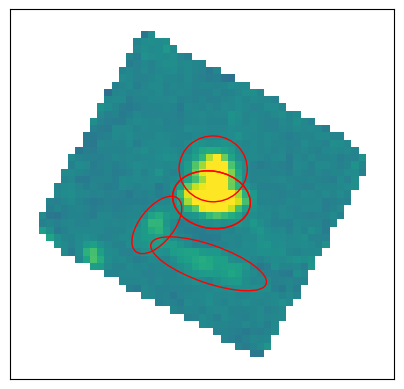

C:\Users\zhigu\AppData\Local\Temp\ipykernel_38744\493653405.py:213: RuntimeWarning: Mean of empty slice
  tmp_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)


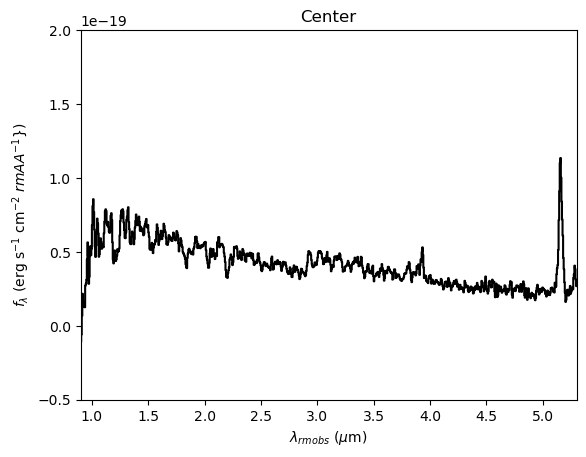

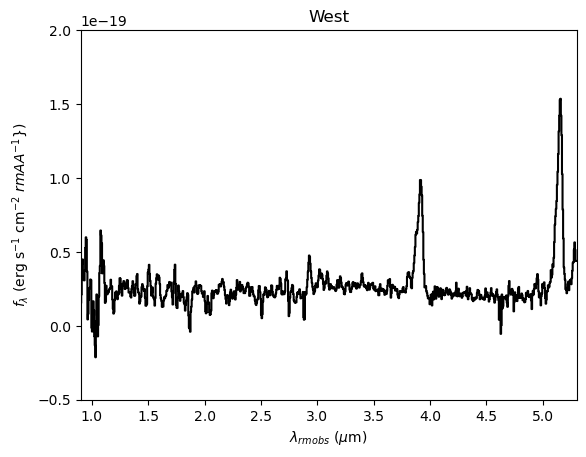

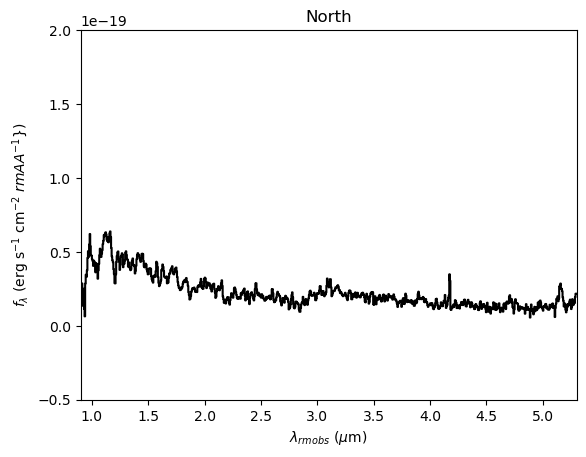

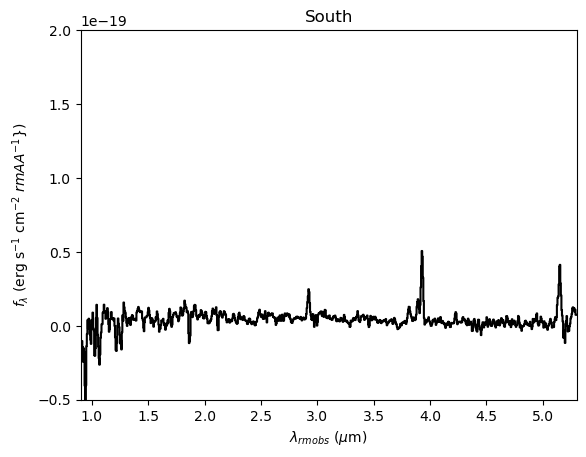

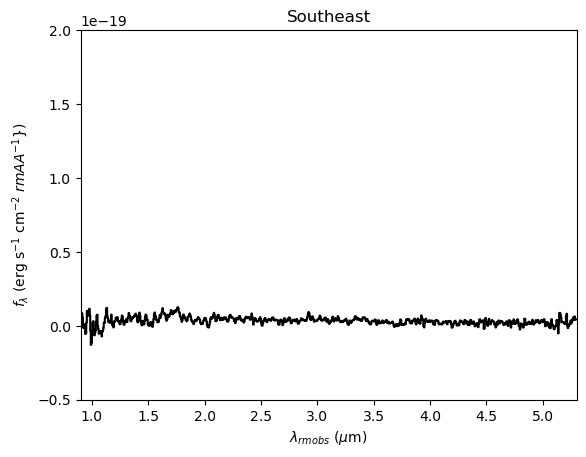

In [ ]:
# import packages
import numpy as np
from astropy.io import fits
from astropy import wcs
from scipy.ndimage import binary_dilation
from scipy.signal import savgol_filter
import sep
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


# grating
grating = 'prism'
#grating = 'G395H'


# Background subtraction of NIRSpec IFU spectra
'''
# import reduced IFU spectra (not subtracted background)
if grating=='prism': s3d_file = 'NIRSpec_IFU/COS-87259_NOBG_prism-clear_s3d.fits' # prism
if grating=='G395H': s3d_file = 'NIRSpec_IFU/COS-87259_NOBG_g395h-f290lp_s3d.fits' # G395H
s3d = fits.open(s3d_file)
hdr = s3d['sci'].header
f3d = s3d['sci'].data
e3d = s3d['err'].data

# wavelength array (unit: micron)
wl0, dwl, wl_len = hdr['CRVAL3'], hdr['CDELT3'], hdr['NAXIS3']
wl = wl0+np.arange(wl_len)*dwl

# create background mask
bkg_mask = np.ones((hdr['NAXIS2'],hdr['NAXIS1']), dtype=bool)

# identify sources from the wavelength-coadded 2D map and mask in bkg_mask

# detection wavelength range
if grating=='prism': wl_det = (wl>0.95) & (wl<5.29) # for prism
if grating=='G395H': wl_det = (wl>2.87) & (wl<5.27) # for G395H

# coadd 2D map using inverse variance weighted stacking
ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)

# mask bad pixels
nan_mask = np.isnan(ivw_stack)
nan_mask = binary_dilation(nan_mask, iterations=2)
ivw_stack[nan_mask] = np.nan

# compute mean background
bkg = sep.Background(ivw_stack, mask=nan_mask, bw=5, bh=5)

# source detection threshold (above 2.5-sigma)
det_thre = 2.5*bkg.globalrms+bkg.back()

# identify sources
obj_pix = np.where((~nan_mask) & (ivw_stack>det_thre))
obj_x, obj_y = obj_pix[1], obj_pix[0]

# mask sources
for y,x in zip(obj_y,obj_x): bkg_mask[y,x] = False

# identify sources from the wavelength-coadded emission line 2D map and mask in bkg_mask
# this is because some pixels only show emission lines but not continuum

# detection wavelength range (coadding H-beta, [OIII]4959,5007, and H-alpha emission lines)
wl_det = ((wl>3.79) & (wl<3.96)) | ((wl>5.12) & (wl<5.18))

# coadd 2D map using inverse variance weighted stacking
ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)

# mask bad pixels
ivw_stack[nan_mask] = np.nan

# compute mean background
bkg = sep.Background(ivw_stack, mask=nan_mask, bw=5, bh=5)

# source detection threshold (above 2.5-sigma)
det_thre = 2.5*bkg.globalrms+bkg.back()

# identify sources
obj_pix = np.where((~nan_mask) & (ivw_stack>det_thre))
obj_x, obj_y = obj_pix[1], obj_pix[0]

# mask sources
for y,x in zip(obj_y,obj_x): bkg_mask[y,x] = False

# mask bad pixels
bkg_mask[nan_mask] = np.nan

# create 1D background spectrum
bkg_flux = np.zeros(wl_len)
for i in range(wl_len): bkg_flux[i] = np.nanmedian(f3d[i][bkg_mask])

# smooth background spectrum, only need for G395H
if grating=='G395H': bkg_flux = savgol_filter(bkg_flux, 50, 1) # for G395H

# subtract background from the 3D flux cube
f3d_bkg_sub = np.zeros_like(f3d)
for i in range(wl_len): f3d_bkg_sub[i] = f3d[i]-bkg_flux[i]
f3d_bkg_sub[:,nan_mask] = np.nan

# write background subtracted 3D IFU spectra cube
s3d['sci'].data = f3d_bkg_sub
if grating=='prism': bkg_sub_file = 'NIRSpec_IFU/COS-87259_BGSUB_prism-clear_s3d.fits'
if grating=='G395H': bkg_sub_file = 'NIRSpec_IFU/COS-87259_BGSUB_g395h-f290lp_s3d.fits'
s3d.writeto(bkg_sub_file, overwrite=True)
'''

# Identifying clumps of COS87259

# background-subtracted IFU spectra
s3d_file = 'NIRSpec_IFU/COS-87259_BGSUB_prism-clear_s3d.fits'
s3d = fits.open(s3d_file)
hdr = s3d['sci'].header
f3d = s3d['sci'].data
e3d = s3d['err'].data

# World Coordinate System (WCS)
w = wcs.WCS(hdr)

# wavelength array (unit: micron)
wl0, dwl, wl_len = hdr['CRVAL3'], hdr['CDELT3'], hdr['NAXIS3']
wl = wl0+np.arange(wl_len)*dwl

# detection wavelength range
wl_det = (wl>0.95) & (wl<5.29) # full spectrum, prism

# coadd 2D map using inverse variance weighted stacking
ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)

# mask bad pixels
nan_mask = np.isnan(ivw_stack)

# background subtraction
bkg = sep.Background(ivw_stack, mask=nan_mask, bw=5, bh=5)
stack_bkg_sub = ivw_stack-bkg
stack_bkg_sub[nan_mask] = np.nan

# source (individual clump) extraction
objects = sep.extract(stack_bkg_sub, 1.5, err=bkg.globalrms, mask=nan_mask)

# calculate Kron radius
r_kron, flag_kron = sep.kron_radius(stack_bkg_sub, objects['x'], objects['y'], objects['a'], objects['b'], objects['theta'], 6, mask=nan_mask)

# print extracted clump information (center, semi-major axis & semi-minor axis, Kron radius, inclination angle)
# 3: central+western clump
# 4: northern clump
# 6: eastern clump
for i in [3,4,6]: print('%7.4f %7.4f %6.4f %6.4f %6.4f %8.4f' % (objects['x'][i], objects['y'][i], objects['a'][i], objects['b'][i], r_kron[i], objects['theta'][i]))

# extract southern clump using only rest-frame optical spectra

# detection wavelength range
wl_det_opt = (wl>2.85) & (wl<5.29) # rest-frame optical

# coadd 2D map using inverse variance weighted stacking
ivw_stack_opt = np.nanmean(f3d[wl_det_opt]/e3d[wl_det_opt]**2,axis=0) / np.nanmean(1./e3d[wl_det_opt]**2,axis=0)

# mask bad pixels
nan_mask_opt = np.isnan(ivw_stack_opt)

# background subtraction
bkg_opt = sep.Background(ivw_stack_opt, mask=nan_mask_opt, bw=5, bh=5)
stack_bkg_sub_opt = ivw_stack_opt-bkg_opt
stack_bkg_sub_opt[nan_mask_opt] = np.nan

# source (individual clump) extraction
objects_opt = sep.extract(stack_bkg_sub_opt, 1.5, err=bkg_opt.globalrms, mask=nan_mask_opt)

# calculate Kron radius
r_kron_opt, flag_kron_opt = sep.kron_radius(stack_bkg_sub_opt, objects_opt['x'], objects_opt['y'], objects_opt['a'], objects_opt['b'], objects_opt['theta'], 6, mask=nan_mask_opt)

# print extracted clump information (center, semi-major axis & semi-minor axis, Kron radius, inclination angle)
# 1: southern clump
print('%7.4f %7.4f %6.4f %6.4f %6.4f %8.4f' % (objects_opt['x'][1], objects_opt['y'][1], objects_opt['a'][1], objects_opt['b'][1], r_kron_opt[1], objects_opt['theta'][1]))


# extract 1D spectra of clumps using elliptical aperture

# clump information
clump_ids = ['Center', 'West', 'North', 'South', 'Southeast']
x = np.array([27.2994, 27.2994, 27.5317, 26.9051, 19.7599]) # center X
y = np.array([24.2436, 24.2436, 28.4938, 15.3950, 20.7517]) # center Y
a = np.array([2.0362, 2.0362, 1.4309, 3.2745, 2.0370]) # semi-major axis
b = np.array([1.4896, 1.4896, 1.3812, 1.0209, 1.0339]) # semi-minor axis
r = np.array([2.6471, 2.6471, 3.2883, 2.5689, 2.2962]) # radius
theta = np.array([-0.1644, -0.1644, -0.0619, -0.3366, 0.9059]) # inclination angle

# plot rest-frame optical wavelength coadded 2D spectra image
m, s = np.nanmean(stack_bkg_sub_opt), np.nanstd(stack_bkg_sub_opt)
plt.imshow(stack_bkg_sub_opt, vmin=m-3*s, vmax=m+3*s, origin='lower')

# plot the elliptical aperture for each clump
for n, clump_id in enumerate(clump_ids):
    e = Ellipse(xy=(x[n], y[n]), width=2.*a[n]*r[n], height=2.*b[n]*r[n], angle=theta[n]*180./np.pi, facecolor='none', edgecolor='r')
    plt.gca().add_patch(e)

plt.xticks([])
plt.yticks([])
plt.show()

# flux zero point (unit: MJy = 1e6 Jy = 1e-17 erg/(s*cm^2*Hz) = 1e-20 W/(m^2*Hz) )
fnu_0 = hdr['pixar_sr']

# clump spectra extraction

for n, clump_id in enumerate(clump_ids):

    # mask bad pixels
    flux_mask = nan_mask
    
    # mask pixels from other clumps
    
    tmp_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)

    if clump_id=='Center':
        tmp_stack[27:,:] = np.nan # these pixels are not from the central clump
        tmp_stack[:,29:] = np.nan # these pixels are not from the central clump
        flux_mask = np.isnan(tmp_stack)
        
    if clump_id=='West':
        tmp_stack[27:,:] = np.nan # these pixels are not from the western clump
        tmp_stack[:,:29] = np.nan # these pixels are not from the western clump
        flux_mask = np.isnan(tmp_stack)
        
    if clump_id=='North':
        tmp_stack[:27,:] = np.nan # these pixels are not from the northern clump
        flux_mask = np.isnan(tmp_stack)
        
    # calculate flux of each clump
    
    f1d, e1d = np.zeros_like(wl), np.zeros_like(wl)
    
    for i in range(wl_len):
    
        f2d, e2d = f3d[i], e3d[i]
        f2d = f2d.astype(f2d.dtype.newbyteorder('='))
        e2d = e2d.astype(e2d.dtype.newbyteorder('='))
        
        aper_flux, aper_flux_err, aper_flux_flag = sep.sum_ellipse(f2d, [x[n]], [y[n]], [a[n]], [b[n]], [theta[n]], [r[n]], mask=flux_mask)
        f1d[i] = aper_flux[0]*fnu_0
        
        aper_err, aper_err_err, aper_err_flag = sep.sum_ellipse(e2d**2, [x[n]], [y[n]], [a[n]], [b[n]], [theta[n]], [r[n]], mask=flux_mask)
        e1d[i] = np.sqrt(aper_err[0])*fnu_0
        
    f1d = f1d*1e-17*3e18/(wl*1e4)**2 # unit: erg/s/cm^2/Angstrom
    e1d = e1d*1e-17*3e18/(wl*1e4)**2 # unit: erg/s/cm^2/Angstrom
    
    # plot clump spectra
    
    #plt.subplot(2,3,n+1)
    plt.plot(wl, f1d, 'k-', ds='steps-mid', label='Kron aperture')
    plt.xlim([0.9,5.3])
    plt.ylim([-5e-20,2e-19])
    plt.xlabel(r'$\lambda_{rm obs}$ ($\mu$m)')
    plt.ylabel(r'$f_{\lambda}$ (erg s$^{-1}$ cm$^{-2}$ ${rm AA}^{-1}$})')
    plt.title(clump_id)
    plt.show()
    
#plt.show()
